# UFC PREDICTION MODEL 2.0 (CatBoost) ###

Notes:
- To start enviroment: venv\Scripts\Activate.ps1

### Import required libraries

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib # for model extraction
import matplotlib.pyplot as plt

### Import Data

In [30]:
df = pd.read_csv("../Data\large_dataset.csv")

# Reverse the dataset to begin with the oldest fight
df = df.iloc[::-1].reset_index(drop=True)


<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\fancy\AppData\Local\Temp\ipykernel_28092\3763960240.py:1: SyntaxWarning: invalid escape sequence '\l'
  df = pd.read_csv("../Data\large_dataset.csv")


### Setup Variables

In [31]:
# Create binary winner label
df['winner_binary'] = df['winner'].map({'Red': 1, 'Blue': 0})

diff_features = [
    'SLpM_total_diff', 'SApM_total_diff', 'sig_str_acc_total_diff',
    'td_acc_total_diff', 'str_def_total_diff', 'td_def_total_diff',
    'sub_avg_diff', 'td_avg_diff', 'age_diff', 'height_diff', 'reach_diff', 'wins_total_diff', 'losses_total_diff'
]

# Drop rows with missing values in key columns
df = df.dropna(subset=diff_features + ['winner_binary'])

# Reverse for chronological ordering
df = df.iloc[::-1].reset_index(drop=True)

# Split dataset
split_idx = int(len(df) * (2 / 3))
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Define features and targets
X_train = train_df[diff_features]
y_train = train_df['winner_binary']
X_test = test_df[diff_features]
y_test = test_df['winner_binary']




### Train the Model

In [32]:
model = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='Accuracy',
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train)
calibrated = CalibratedClassifierCV(model, method='sigmoid', cv=5)
calibrated.fit(X_train, y_train)

0:	learn: 0.6837340	total: 10.1ms	remaining: 12.1s
100:	learn: 0.7440392	total: 294ms	remaining: 3.2s
200:	learn: 0.7663489	total: 564ms	remaining: 2.8s
300:	learn: 0.7892007	total: 858ms	remaining: 2.56s
400:	learn: 0.8128830	total: 1.13s	remaining: 2.25s
500:	learn: 0.8345794	total: 1.4s	remaining: 1.96s
600:	learn: 0.8562778	total: 1.66s	remaining: 1.66s
700:	learn: 0.8753731	total: 1.94s	remaining: 1.38s
800:	learn: 0.8904255	total: 2.21s	remaining: 1.1s
900:	learn: 0.9038414	total: 2.48s	remaining: 823ms
1000:	learn: 0.9155454	total: 2.74s	remaining: 545ms
1100:	learn: 0.9274526	total: 3.02s	remaining: 272ms
1199:	learn: 0.9354611	total: 3.28s	remaining: 0us
0:	learn: 0.6567363	total: 2.92ms	remaining: 3.5s
100:	learn: 0.7404863	total: 241ms	remaining: 2.63s
200:	learn: 0.7717140	total: 487ms	remaining: 2.42s
300:	learn: 0.7986642	total: 743ms	remaining: 2.22s
400:	learn: 0.8260531	total: 989ms	remaining: 1.97s
500:	learn: 0.8521502	total: 1.24s	remaining: 1.73s
600:	learn: 0.8760

,estimator,<catboost.cor...002584B1C6AF0>
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'


### Predict and Evaluate

In [33]:
# Predict + evaluate
y_pred = calibrated.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.651337400281558

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.56      0.48       617
           1       0.79      0.69      0.74      1514

    accuracy                           0.65      2131
   macro avg       0.61      0.62      0.61      2131
weighted avg       0.69      0.65      0.66      2131

Confusion Matrix:
 [[ 344  273]
 [ 470 1044]]


In [34]:
# Save model for external use
joblib.dump(calibrated, "CatBoost_ufc_model.pkl")


['CatBoost_ufc_model.pkl']

### Visualize/Analyze

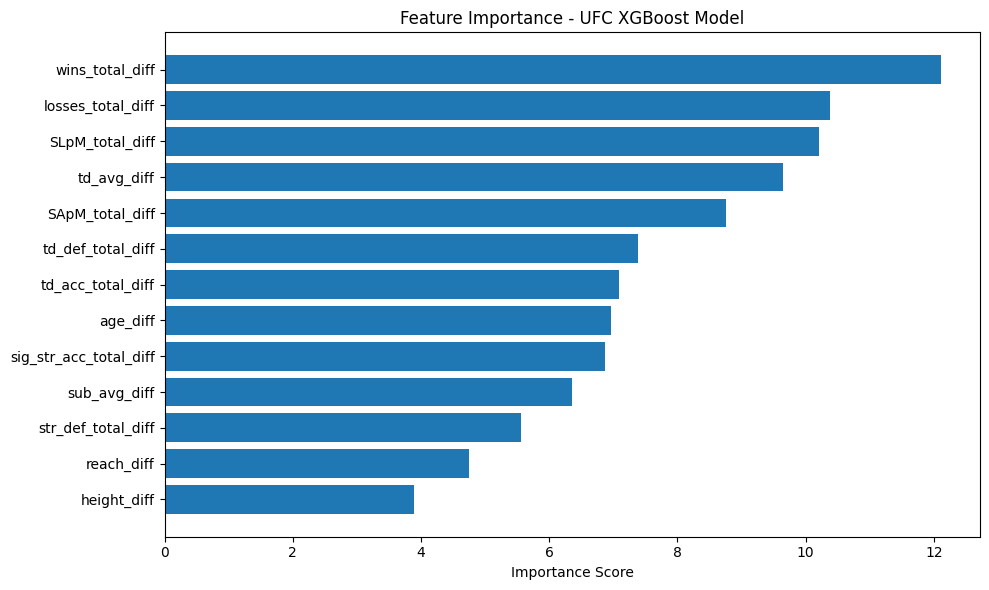

In [35]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': diff_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - UFC XGBoost Model')
plt.gca().invert_yaxis()  # Most important at the top
plt.tight_layout()
plt.show()